# Deep-LDA collective variable: training, well-tempered metadynamics e diagnostica

Questo notebook implementa da capo la pipeline **Deep-LDA + metadinamica ben temperata (Well-Tempered MetaD)** per il dipeptide dell'alanina, seguendo l'architettura e gli iperparametri raccomandati dal riferimento metodologico (Bonati, Rizzi & Parrinello, *J. Phys. Chem. Lett.* 2020, 11, 2998–3004, "Data-driven collective variables for enhanced sampling"; si veda anche PLUMED Masterclass 22-05 e il Cap. 5–6 di Trizio, *Machine Learning and Molecular Dynamics*, Tesi di Dottorato, Università di Milano-Bicocca, 2023).

**Struttura del notebook**

1. Setup, configurazione e funzioni ausiliarie
2. Caricamento del dataset dagli stati metastabili non biassati (A, B)
3. Addestramento della rete Deep-LDA con i parametri raccomandati
4. Diagnostica del training (loss, spazio latente, istogramma CV, stima di σ intra-basino)
5. Sensitivity analysis (singolo modello e multi-seed)
6. Sweep diagnostici di architettura e funzione di attivazione
7. Esportazione del modello in TorchScript
8. Simulazione con metadinamica ben temperata guidata dalla CV Deep-LDA
9. Diagnostica post-simulazione (convergenza, reweighting, FES, block analysis)

> **Nota:** le celle che invocano `gmx_mpi mdrun` o `plumed driver` stampano il comando da eseguire nel terminale (secondo la convenzione già adottata in `04_full.ipynb`/`05_test.ipynb`), poiché l'esecuzione delle simulazioni MD non è demandata al kernel del notebook.


## 1. Setup, configurazione e funzioni ausiliarie

In [1]:
import os
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import TQDMProgressBar

from mlcolvar.cvs import DeepLDA
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_files, load_dataframe
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.fes import compute_fes
from mlcolvar.explain import sensitivity_analysis
import mlcolvar.utils.plot
import plumed


In [2]:
# Configurazione (coerente con 04_full.ipynb / 05_test.ipynb)
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data2"
GMX_CMD     = "gmx_mpi"

STRIDE        = 100
sample_steps  = 1_000_000
sample_stride = 100

os.chdir(BASE_DIR)
os.getcwd()


'/home/dani/wslcoding/MCFM/ML-CV'

In [3]:
# Funzioni ausiliarie (identiche a quelle di 04_full.ipynb / 05_test.ipynb)

def clean(folder='./'):
    # Rimuove i file di backup di una simulazione (non tocca gli output principali).
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

def clean_true(folder='./'):
    # Rimuove tutti gli output di una simulazione dalla cartella indicata.
    subprocess.run("rm -f bck.* COLVAR HILLS KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

def execute(command, folder, background=False):
    # Esegue un comando di shell nella cartella indicata.
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output=True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

def augment_periodic(cv, weights=None, bandwidth=0.1):
    # Aggiunge punti immagine oltre i bordi periodici (-pi, pi) per una stima
    # corretta della FES via KDE in prossimita' dei limiti del dominio.
    mask = (cv < -np.pi + 3 * bandwidth)
    index = np.argwhere(mask)[:, 0]
    cv = np.insert(cv, index, cv[mask] + 2 * np.pi)
    if weights is not None:
        weights = np.insert(weights, index, weights[mask])

    mask = (cv > np.pi - 5 * bandwidth) & (cv < np.pi)
    index = np.argwhere(mask)[:, 0]
    cv = np.insert(cv, np.argwhere(mask)[:, 0], cv[mask] - 2 * np.pi)
    if weights is not None:
        weights = np.insert(weights, index, weights[mask])

    return cv, weights

def plot_ramachandran(x, y, z, ax=None, cv_label='Deep-LDA CV'):
    # Ramachandran plot (phi, psi) colorato secondo il valore della CV.
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.), dpi=100)
        ax.set_title('Ramachandran plot')
    h = ax.hexbin(x, y, C=z, cmap='fessa')
    cbar = plt.colorbar(h, ax=ax)
    cbar.set_label(cv_label)
    ax.set_xlabel(r'$\phi$ [rad]')
    ax.set_ylabel(r'$\psi$ [rad]')
    return ax

def plot_cv_histogram(s, label=None, ax=None, **kwargs):
    # Istogramma dei valori della CV.
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.), dpi=100)
        ax.set_title('Histogram')
    if isinstance(s, torch.Tensor):
        s = s.squeeze(-1).detach().numpy()
    ax.hist(s, **kwargs)
    if label is not None:
        ax.set_xlabel(label)
    return ax

def set_seed(seed):
    # Fissa il seed per riproducibilita' (numpy, torch, lightning).
    lightning.seed_everything(seed, workers=True)
    return seed


## 2. Caricamento del dataset dagli stati metastabili

Si assume che le simulazioni non biassate degli stati A e B (Cap. "1.0 Unbiased simulations", `04_full.ipynb`) siano già state completate e che i rispettivi file `COLVAR` si trovino in `0_unbiased-sA/` e `0_unbiased-sB/`. Come descrittori si usano le 45 distanze tra gli atomi pesanti del dipeptide dell'alanina, coerentemente con l'architettura del riferimento (Bonati et al. 2020; Trizio 2023, Sez. 6.2.3).

In [4]:
torch.set_float32_matmul_precision('high')

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {accelerator.upper()}")


Training on: GPU


In [5]:
filenames = [f"{DATA_DIR}/0_unbiased-sA/COLVAR",
             f"{DATA_DIR}/0_unbiased-sB/COLVAR"]

n_states = len(filenames)

dataset, colvar = create_dataset_from_files(
    filenames,
    filter_args={'regex': 'd_'},   # distanze tra atomi pesanti
    create_labels=True,
    return_dataframe=True,
)

datamodule = DictModule(dataset, lengths=[0.8, 0.2])

n_input = dataset['data'].shape[-1]
print(f"Numero di stati: {n_states} | Numero di descrittori in ingresso: {n_input}")


Class 0 dataframe shape:  (5001, 53)
Class 1 dataframe shape:  (5001, 53)

 - Loaded dataframe (10002, 53): ['time', 'phi', 'psi', 'theta', 'xi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (10002, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15

## 3. Addestramento della rete Deep-LDA (parametri raccomandati)

L'architettura e gli iperparametri seguono quelli raccomandati per il dipeptide dell'alanina nel lavoro originale (Bonati, Rizzi & Parrinello, *JPCL* 2020) e nel PLUMED Masterclass 22-05:

| Parametro | Valore | Note |
|---|---|---|
| Nodi per strato | `[n_input, 30, 30, 5]` | 5 uscite pre-LDA, poi proiezione LDA a `n_states - 1 = 1` componente |
| Funzione di attivazione | `tanh` | più stabile di ReLU per questa architettura poco profonda |
| Ottimizzatore | Adam, `lr = 1e-3` | |
| Regolarizzazione L2 | `weight_decay = 1e-5` | |
| Regolarizzazione S_w | `sw_reg = 0.05` | stabilizza il calcolo della matrice di scatter within-class (Eq. 6.1, Trizio 2023) |
| Epoche massime | 500 | con early stopping |
| Early stopping | `patience = 50`, `min_delta = 0.1` su `valid_loss` | |

Il seed è fissato esplicitamente per garantire la riproducibilità del modello di riferimento (usato poi nella metadinamica); la sensitivity analysis multi-seed (Sez. 5.2) quantifica invece la variabilità indotta dall'inizializzazione.

In [6]:
#------------- PARAMETRI RACCOMANDATI -------------
SEED              = 42

# nodes             = [n_input, 30, 30, 5]
nodes             = [n_input, 24, 12, 5]
activation        = 'tanh'

lrate             = 0.001
sw_reg            = 0.05
l2_reg            = 1e-5

num_epochs        = 500
es_patience       = 50
es_min_delta      = 0.1

log_every         = 100
#----------------------------------------------------

set_seed(SEED)

nn_args = {'activation': activation}
options = {'nn': nn_args}

# MODELLO
model = DeepLDA(nodes, n_states=n_states, options=options)

# OTTIMIZZATORE
model.optimizer_name = "Adam"
model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}

# REGOLARIZZAZIONE della matrice S_w
model.sw_reg = sw_reg

model


Seed set to 42


DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=24, bias=True)
      (1): Tanh()
      (2): Linear(in_features=24, out_features=12, bias=True)
      (3): Tanh()
      (4): Linear(in_features=12, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)

In [7]:
# Callback e trainer
metrics = MetricsCallback()
early_stopping = EarlyStopping(
    monitor="valid_loss",
    min_delta=es_min_delta,
    patience=es_patience,
    mode="min",
)
tqdm_progress_bar = TQDMProgressBar(refresh_rate=50)

trainer = lightning.Trainer(
    callbacks=[metrics, early_stopping, tqdm_progress_bar],
    max_epochs=num_epochs,
    logger=None,
    enable_checkpointing=False,
    accelerator=accelerator,
    enable_progress_bar=True,
    enable_model_summary=True,
)

trainer.fit(model, datamodule)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-07-13 13:53:06.698315: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-13 13:53:07.381585: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-13 13:53:09.475643: I tensorflow/core/util/port.cc:153] oneDNN cust

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  1.5 K │ train │ 2.9 K │  [1, 45] │    [1, 5] │
│ 3 │ lda     │ LDA                   │      0 │ train │    10 │   [1, 5] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 1.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 K                                                                                                
Total estimated model params size (MB): 0.006                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 2.9 K

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## 4. Diagnostica del training

### 4.1 Curva di apprendimento (training / validation loss)

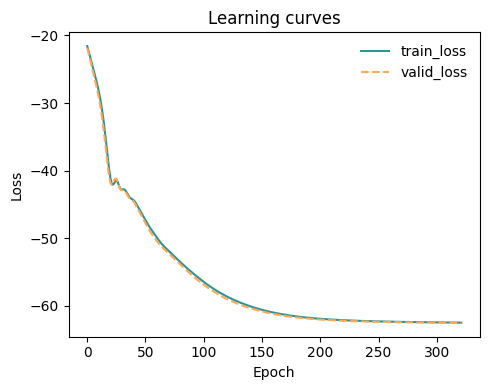

In [9]:
ax = plot_metrics(
    metrics.metrics,
    labels=['train_loss', 'valid_loss'],
    keys=['train_loss_epoch', 'valid_loss'],
    linestyles=['-', '--'], colors=['fessa1', 'fessa5'],
    yscale='linear',
)
plt.tight_layout()


### 4.2 Spazio latente pre-LDA

Distribuzione, per stato metastabile, di ciascuno dei 5 nodi in uscita dalla rete **prima** della proiezione LDA. Una buona separazione già a questo livello indica che la rete ha appreso una rappresentazione non lineare utile alla discriminazione (Cap. 6, Trizio 2023).

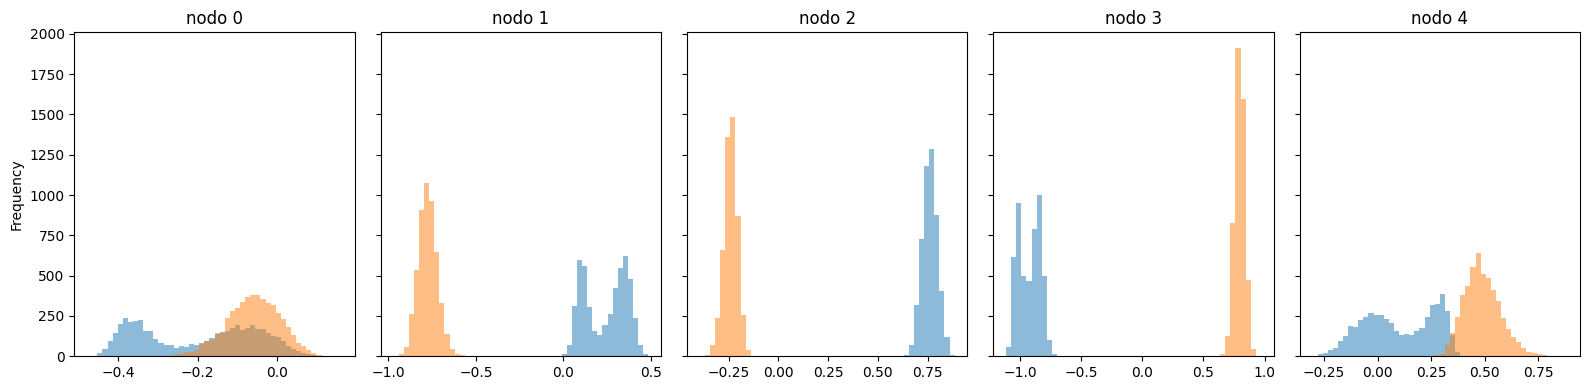

In [10]:
X_dist = colvar.filter(like='d_', axis=1)
X = torch.tensor(X_dist.values, dtype=torch.float32)
y = torch.tensor(colvar['labels'].values, dtype=torch.long)

model.eval()
with torch.no_grad():
    hidden = model.forward_nn(X).numpy()

df_h = pd.DataFrame(hidden)
df_h['label'] = y

fig, axs = plt.subplots(1, nodes[-1], figsize=(16, 4), sharey=True)
for ax, desc in zip(axs.flatten(), range(nodes[-1])):
    df_h.pivot(columns='label')[desc].plot.hist(bins=50, alpha=0.5, ax=ax, legend=False)
    ax.set_title(f'nodo {desc}')
plt.tight_layout()


### 4.3 Proiezione finale: Ramachandran plot e istogramma della CV Deep-LDA

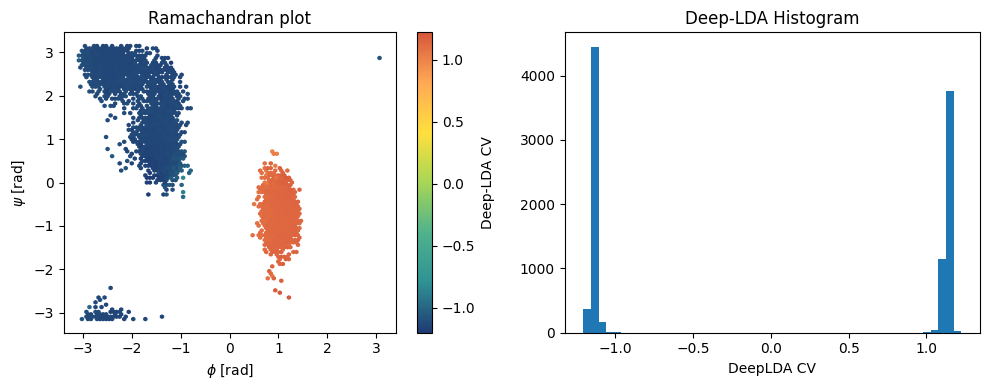

In [11]:
_, axs = plt.subplots(1, 2, figsize=(10, 4.), dpi=100)

with torch.no_grad():
    s = model(X)

axs[0].set_title('Ramachandran plot')
plot_ramachandran(colvar['phi'], colvar['psi'], s, ax=axs[0])

axs[1].set_title('Deep-LDA Histogram')
plot_cv_histogram(s, label="DeepLDA CV", bins=50, ax=axs[1])

plt.tight_layout()


### 4.4 Stima di $\sigma$ della CV (calcolo intra-basino corretto)

La deviazione standard "ingenua" calcolata sull'intero dataset **sovrastima** sistematicamente la larghezza tipica dei bacini, poiché include anche la separazione tra gli stati. Il valore fisicamente rilevante per impostare `SIGMA` in `METAD` è la deviazione standard **intra-basino**, calcolata per ciascuno stato metastabile e poi mediata (si veda `05_test.ipynb`, sezione "sigma estimation").

State A: mean = -1.1365, sigma = 0.0179, frames = 5001
State B: mean = 1.1340, sigma = 0.0182, frames = 5001


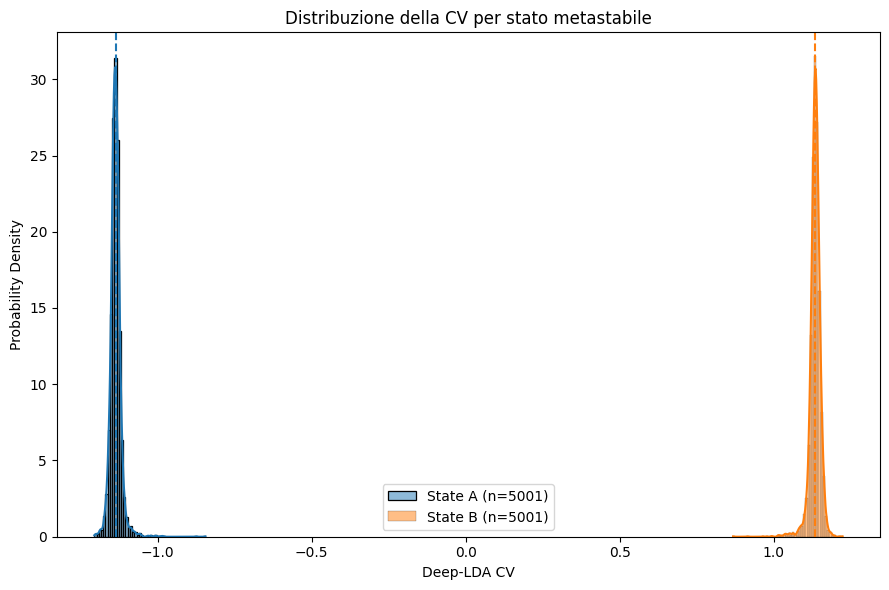


Sigma intra-basino (media sugli stati) : 0.0180  <-- valore raccomandato per SIGMA
Sigma 'naive' sull'intero dataset       : 1.1354  (sovrastimato, NON usare per SIGMA)


In [12]:
s_np = s.squeeze(-1).detach().numpy() if isinstance(s, torch.Tensor) else np.asarray(s)
labels_np = colvar['labels'].values

state_names = {0: 'State A', 1: 'State B'}
unique_states = sorted(np.unique(labels_np))
palette = {0: 'tab:blue', 1: 'tab:orange'}

sigma_per_state = {}
plt.figure(figsize=(9, 6))

for st in unique_states:
    cv_state = s_np[labels_np == st]
    n_frames = len(cv_state)
    mean_val, std_val = np.mean(cv_state), np.std(cv_state)
    sigma_per_state[st] = std_val

    name = state_names.get(int(st), f'State {int(st)}')
    color = palette.get(int(st))
    print(f"{name}: mean = {mean_val:.4f}, sigma = {std_val:.4f}, frames = {n_frames}")

    sns.histplot(cv_state, kde=True, stat="density", color=color, alpha=0.5, bins=50,
                 label=f'{name} (n={n_frames})')
    plt.axvline(mean_val, color=color, linestyle="--", linewidth=1.5)

sigma_intra = float(np.mean(list(sigma_per_state.values())))
sigma_naive = float(np.std(s_np))

plt.xlabel('Deep-LDA CV')
plt.ylabel('Probability Density')
plt.title('Distribuzione della CV per stato metastabile')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nSigma intra-basino (media sugli stati) : {sigma_intra:.4f}  <-- valore raccomandato per SIGMA")
print(f"Sigma 'naive' sull'intero dataset       : {sigma_naive:.4f}  (sovrastimato, NON usare per SIGMA)")


## 5. Sensitivity analysis

### 5.1 Rilevanza dei descrittori (singolo modello)

La sensitivity analysis stima la rilevanza di ciascun descrittore di ingresso a partire dalle derivate della CV $s$ rispetto ai descrittori stessi, valutate sul dataset di training (`mlcolvar.explain.sensitivity_analysis`). Si riportano sia la versione aggregata (`per_class=False`) sia quella disaggregata per stato metastabile (`per_class=True`), utile a verificare se la rilevanza dei descrittori è omogenea tra i due bacini.

KEY:  data


KEY:  labels




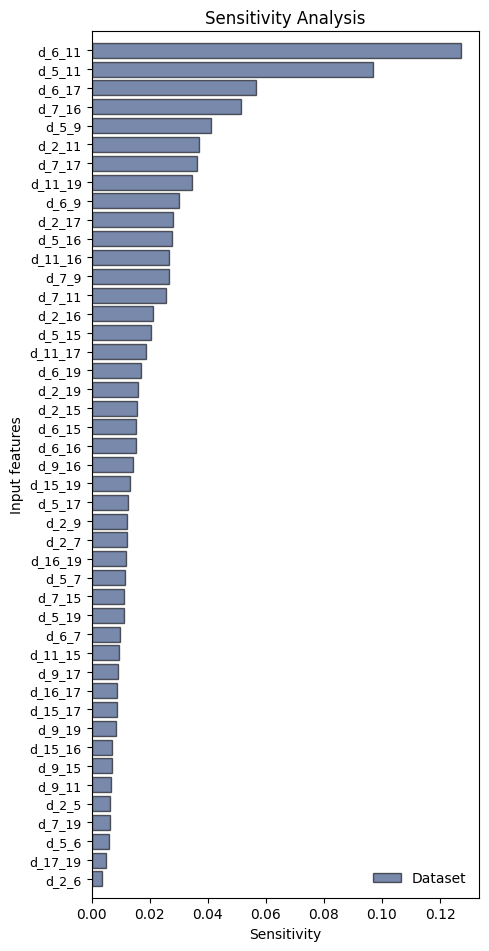

In [13]:
results_global = sensitivity_analysis(
    model, dataset, feature_names=dataset.feature_names,
    per_class=False, plot_mode='barh',
)


KEY:  data


KEY:  labels




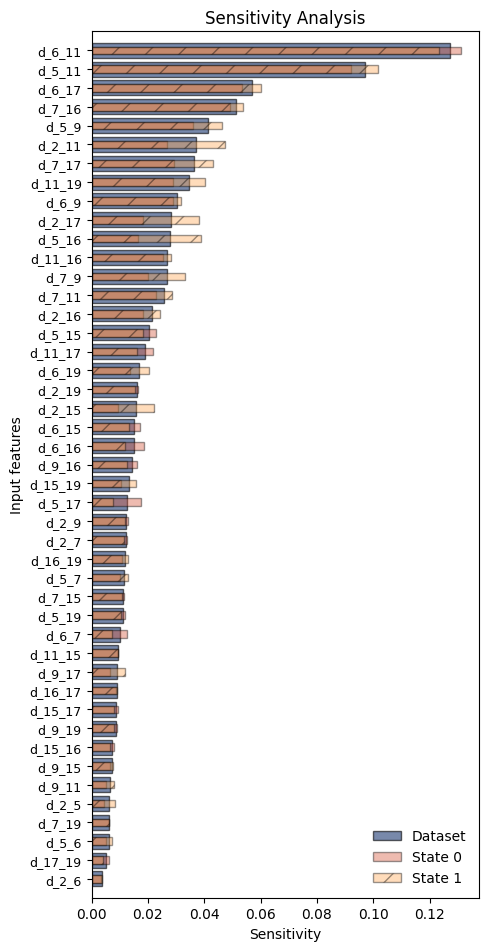

In [14]:
results_per_class = sensitivity_analysis(
    model, dataset, feature_names=dataset.feature_names,
    per_class=True, plot_mode='barh',
)


### 5.2 Sensitivity analysis multi-seed

Un singolo addestramento può produrre una stima della rilevanza dei descrittori dipendente dall'inizializzazione stocastica dei pesi. Per quantificare la robustezza del ranking dei descrittori si addestrano $K$ modelli identici (stessa architettura e iperparametri, seed diversi) e si aggregano le rilevanze ottenute, riportando media e deviazione standard per ciascun descrittore.

In [15]:
N_SEEDS = 5
seeds = [SEED + i for i in range(N_SEEDS)]

sensitivity_records = []   # lista di dict: {seed, feature, relevance}
trained_models = []

for seed in seeds:
    set_seed(seed)

    seed_model = DeepLDA(nodes, n_states=n_states, options=options)
    seed_model.optimizer_name = "Adam"
    seed_model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}
    seed_model.sw_reg = sw_reg

    seed_metrics = MetricsCallback()
    seed_early_stopping = EarlyStopping(monitor="valid_loss", min_delta=es_min_delta,
                                         patience=es_patience, mode="min")
    seed_trainer = lightning.Trainer(
        callbacks=[seed_metrics, seed_early_stopping],
        max_epochs=num_epochs, logger=None, enable_checkpointing=False,
        accelerator=accelerator, enable_progress_bar=False, enable_model_summary=False,
    )
    seed_trainer.fit(seed_model, datamodule)
    trained_models.append(seed_model)

    res = sensitivity_analysis(
        seed_model, dataset, feature_names=dataset.feature_names,
        per_class=False, plot_mode=None,
    )
    # 'res' espone la rilevanza per descrittore (dict feature -> valore)
    relevance = res['feature_relevance'] if isinstance(res, dict) and 'feature_relevance' in res else res
    for feat, val in dict(relevance).items():
        sensitivity_records.append({'seed': seed, 'feature': feat, 'relevance': float(val)})

    print(f"seed {seed}: training completato ({seed_trainer.current_epoch} epoche)")


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


KEY:  data


KEY:  labels




TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
sens_df = pd.DataFrame(sensitivity_records)

summary = (sens_df.groupby('feature')['relevance']
           .agg(['mean', 'std'])
           .sort_values('mean', ascending=False))

top_n = 15
top_features = summary.head(top_n)

fig, ax = plt.subplots(figsize=(7, 6), dpi=100)
ax.barh(top_features.index[::-1], top_features['mean'][::-1],
        xerr=top_features['std'][::-1], color='tab:blue', alpha=0.8, capsize=3)
ax.set_xlabel(f'Rilevanza media ± dev. std. su {N_SEEDS} seed')
ax.set_title('Multi-seed sensitivity analysis (top descrittori)')
plt.tight_layout()
plt.show()

# coefficiente di variazione, come misura di robustezza del ranking
summary['cv'] = summary['std'] / summary['mean'].abs()
print("Descrittori più stabili tra i seed (CV più basso, tra i top", top_n, "per rilevanza media):")
print(summary.head(top_n).sort_values('cv')[['mean', 'std', 'cv']])


## 6. Sweep diagnostici: architettura e funzione di attivazione

### 6.1 Numero di uscite della rete (pre-LDA)

Confronto qualitativo dell'effetto della dimensione dello strato di uscita (che precede la proiezione LDA) sulla qualità della CV risultante, a parità di tutti gli altri iperparametri.

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


NN outputs = 10


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


NN outputs = 5


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


NN outputs = 3


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


NN outputs = 1


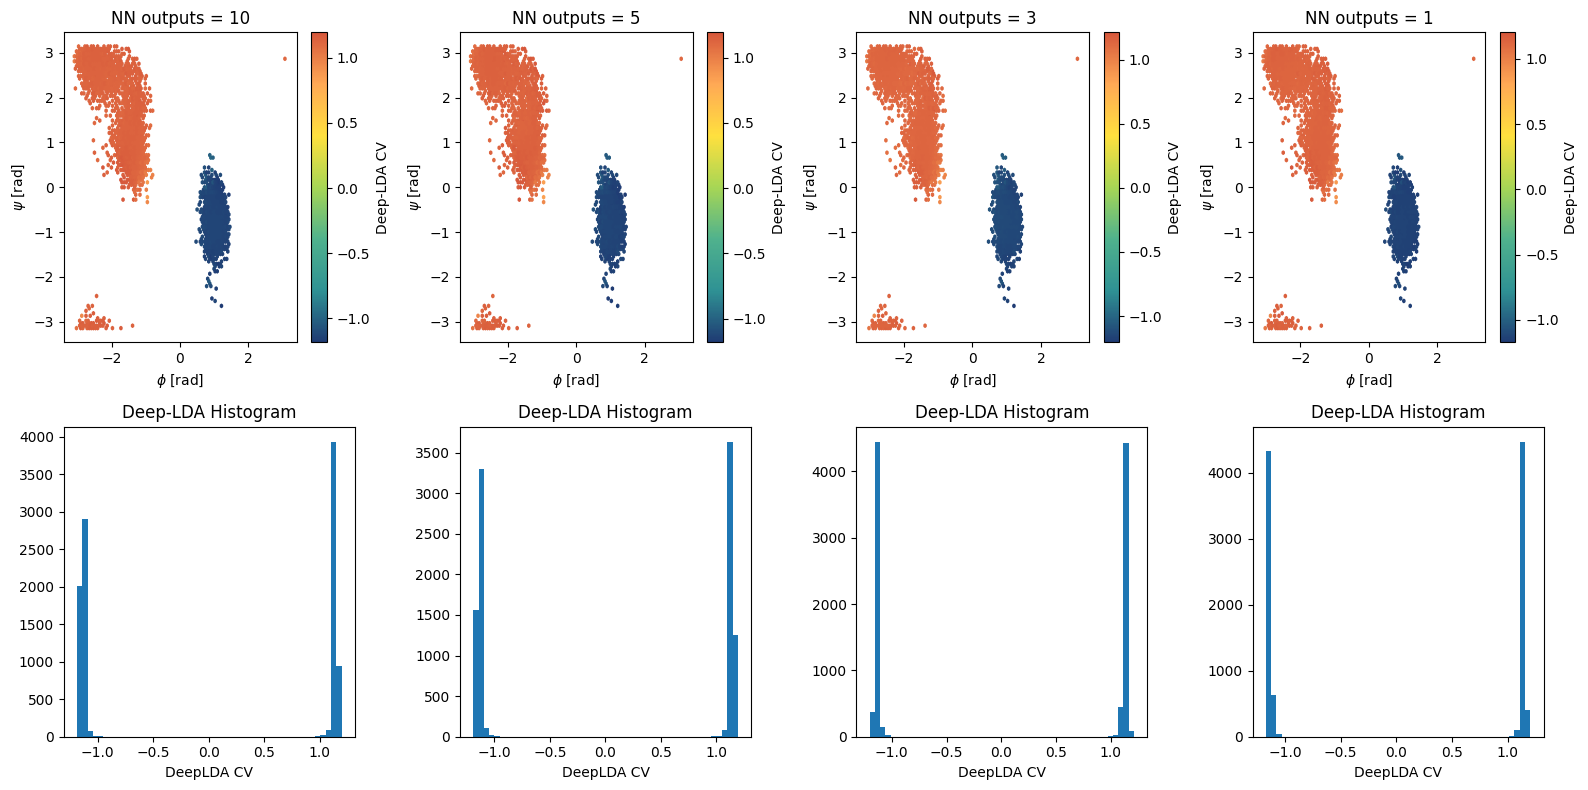

In [16]:
nn_out_values = [10, 5, 3, 1]

fig, axs = plt.subplots(2, len(nn_out_values), figsize=(16, 8), dpi=100)

for i, out in enumerate(nn_out_values):
    print(f'NN outputs = {out}')
    set_seed(SEED)

    arch_nodes = [n_input, 30, 30, out]
    arch_model = DeepLDA(arch_nodes, n_states=n_states, options=options)
    arch_model.optimizer_name = "Adam"
    arch_model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}
    arch_model.sw_reg = sw_reg

    arch_metrics = MetricsCallback()
    arch_early_stopping = EarlyStopping(monitor="valid_loss", min_delta=es_min_delta,
                                         patience=es_patience, mode="min")
    arch_trainer = lightning.Trainer(
        callbacks=[arch_metrics, arch_early_stopping],
        max_epochs=num_epochs, logger=None, enable_checkpointing=False,
        accelerator=accelerator, enable_progress_bar=False, enable_model_summary=False,
    )
    arch_trainer.fit(arch_model, datamodule)

    arch_model.eval()
    with torch.no_grad():
        s_arch = arch_model(X)

    axs[0][i].set_title(f'NN outputs = {out}')
    plot_ramachandran(colvar['phi'], colvar['psi'], s_arch, ax=axs[0][i])
    axs[1][i].set_title('Deep-LDA Histogram')
    plot_cv_histogram(s_arch, label="DeepLDA CV", bins=50, ax=axs[1][i])

plt.tight_layout()


### 6.2 Funzione di attivazione

Si confrontano le funzioni di attivazione più comuni per reti feed-forward poco profonde (`tanh`, `relu`, `sigmoid`, `elu`), mantenendo fissa l'architettura raccomandata `[n_input, 30, 30, 5]`. Oltre alla curva di loss, si confronta la qualità della separazione ottenuta in termini di rapporto di Fisher $F = (\mu_A-\mu_B)^2/(\sigma_A^2+\sigma_B^2)$ (Eq. 6.4, Trizio 2023) sulla CV finale.

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


activation = tanh


/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


activation = relu


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


activation = leaky_relu


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


activation = softplus


`Trainer.fit` stopped: `max_epochs=500` reached.
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


activation = shifted_softplus


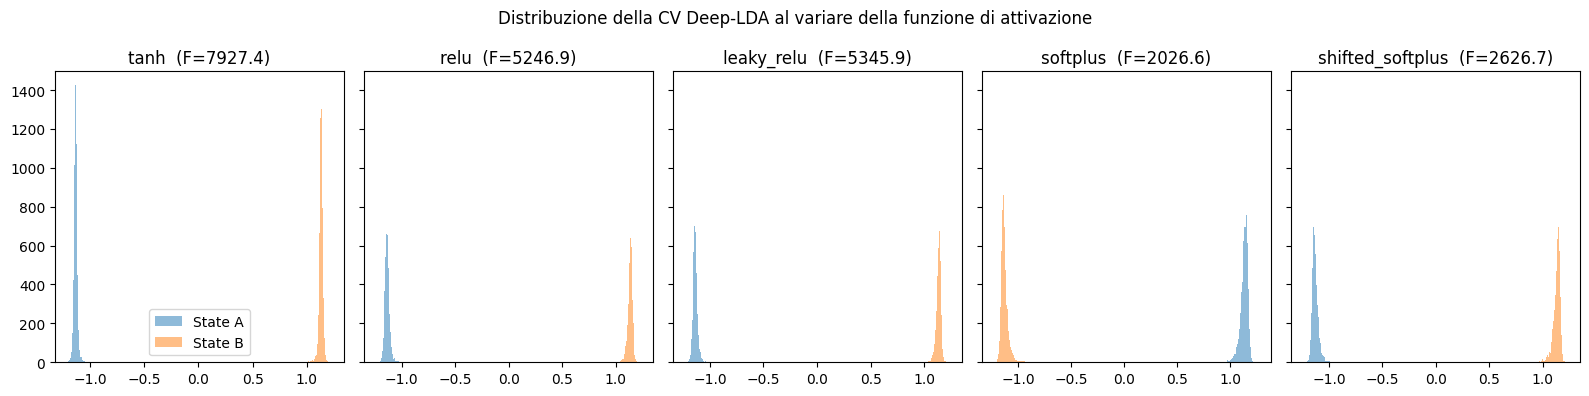

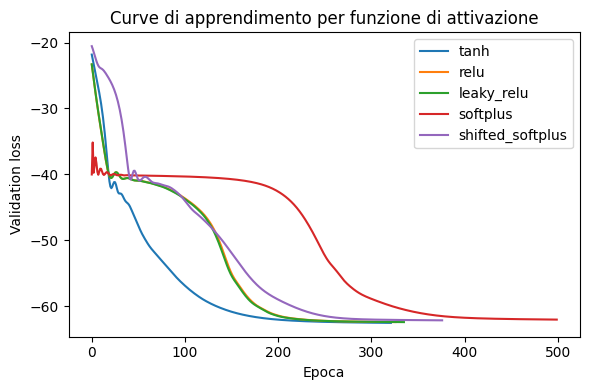

                  final_valid_loss  n_epochs  fisher_ratio
tanh                    -62.557686     322.0   7927.426758
relu                    -62.431900     327.0   5246.857422
leaky_relu              -62.440655     336.0   5345.897949
softplus                -62.059662     500.0   2026.580933
shifted_softplus        -62.170593     377.0   2626.656738


In [21]:
activations_to_test = ['tanh', 'relu', 'leaky_relu', 'softplus','shifted_softplus']

activation_results = {}

fig_hist, axs_hist = plt.subplots(1, len(activations_to_test), figsize=(16, 4), dpi=100, sharey=True)
fig_loss, ax_loss = plt.subplots(figsize=(6, 4), dpi=100)

for i, act in enumerate(activations_to_test):
    print(f'activation = {act}')
    set_seed(SEED)

    act_options = {'nn': {'activation': act}}
    act_model = DeepLDA(nodes, n_states=n_states, options=act_options)
    act_model.optimizer_name = "Adam"
    act_model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}
    act_model.sw_reg = sw_reg

    act_metrics = MetricsCallback()
    act_early_stopping = EarlyStopping(monitor="valid_loss", min_delta=es_min_delta,
                                        patience=es_patience, mode="min")
    act_trainer = lightning.Trainer(
        callbacks=[act_metrics, act_early_stopping],
        max_epochs=num_epochs, logger=None, enable_checkpointing=False,
        accelerator=accelerator, enable_progress_bar=False, enable_model_summary=False,
    )
    act_trainer.fit(act_model, datamodule)

    act_model.eval()
    with torch.no_grad():
        s_act = act_model(X).squeeze(-1).numpy()

    mu_A, mu_B = s_act[labels_np == 0].mean(), s_act[labels_np == 1].mean()
    var_A, var_B = s_act[labels_np == 0].var(), s_act[labels_np == 1].var()
    fisher_ratio = (mu_A - mu_B) ** 2 / (var_A + var_B)

    activation_results[act] = {
        'final_valid_loss': float(act_metrics.metrics['valid_loss'][-1]),
        'n_epochs': act_trainer.current_epoch,
        'fisher_ratio': float(fisher_ratio),
    }

    # loss curve
    ax_loss.plot(act_metrics.metrics['valid_loss'], label=act)

    # histogram
    axs_hist[i].hist(s_act[labels_np == 0], bins=40, alpha=0.5, label='State A')
    axs_hist[i].hist(s_act[labels_np == 1], bins=40, alpha=0.5, label='State B')
    axs_hist[i].set_title(f'{act}  (F={fisher_ratio:.1f})')

axs_hist[0].legend()
fig_hist.suptitle('Distribuzione della CV Deep-LDA al variare della funzione di attivazione')
fig_hist.tight_layout()

ax_loss.set_xlabel('Epoca')
ax_loss.set_ylabel('Validation loss')
ax_loss.set_yscale('linear')
ax_loss.legend()
ax_loss.set_title('Curve di apprendimento per funzione di attivazione')
fig_loss.tight_layout()
plt.show()

print(pd.DataFrame(activation_results).T)


## 7. Esportazione del modello di riferimento

Si esporta in formato TorchScript **il modello addestrato con il seed di riferimento** (Sez. 3), non i modelli dei diversi sweep diagnostici, che restano confinati all'analisi delle Sez. 5–6.

In [22]:
folder_ml = DATA_DIR / "7_deeplda-paper/"
Path(folder_ml).mkdir(parents=True, exist_ok=True)

model.eval()
model.to_torchscript(str(folder_ml / "model.ptc"), method="trace")

print(f"Modello esportato in: {folder_ml / 'model.ptc'}")


/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/core/module.py:1549: `LightningModule.to_torchscript` has been deprecated in v2.7 and will be removed in v2.8. TorchScript is deprecated in PyTorch. Use `torch.export.export()` for model exporting instead. See https://pytorch.org/docs/stable/export.html for more information.


Modello esportato in: /home/dani/wslcoding/MCFM/ML-CV/data2/7_deeplda-paper/model.ptc


## 8. Metadinamica ben temperata guidata dalla CV Deep-LDA

Si utilizza la variante **well-tempered** della metadinamica (Barducci, Bussi & Parrinello, *Phys. Rev. Lett.* 2008, 100, 020603), che modula l'altezza dei gaussiani depositati per garantire la convergenza della stima della superficie di energia libera (Sez. 2.3, Trizio 2023). I parametri sono quelli raccomandati dal riferimento metodologico e dal PLUMED Masterclass 22-05:

| Parametro | Valore | Motivazione |
|---|---|---|
| `PACE` | 500 | intervallo (in passi MD) tra depositi di gaussiani |
| `HEIGHT` | 1.2 kJ/mol | altezza iniziale del gaussiano |
| `BIASFACTOR` | 8 | fattore di bias (γ) della metadinamica ben temperata |
| `SIGMA` | `sigma_intra` (Sez. 4.4) | larghezza del gaussiano, stimata dalla fluttuazione intra-basino della CV nella simulazione non biassata, anziché fissata arbitrariamente |
| `GRID_MIN`/`GRID_MAX` | −π, π | intervallo della griglia per l'accumulo del bias |

Se la stima di `sigma_intra` risultasse anomala (es. per un numero insufficiente di frame nel dataset di training), si ricade sul valore di letteratura raccomandato `SIGMA = 0.3`.

attenzione!! bias 10 crea problemi con sigma piccole

In [ ]:
SIGMA_FALLBACK = 0.3

sigma_metad = sigma_intra if np.isfinite(sigma_intra) and sigma_intra > 0 else SIGMA_FALLBACK
print(f"SIGMA usato in METAD: {sigma_metad:.4f}  (fallback di letteratura: {SIGMA_FALLBACK})")

PACE_METAD       = 500
HEIGHT_METAD     = 1.2   # kJ/mol
BIASFACTOR_METAD = 8.0
STRIDE_ML        = 100


SIGMA usato in METAD: 0.0180  (fallback di letteratura: 0.3)


In [24]:
execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_ml)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_ml)


Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [46]:
# SCRITTURA DEL FILE DI INPUT PLUMED
with open(folder_ml / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

# Well-tempered metadynamics sulla CV Deep-LDA (parametri raccomandati)
metad: METAD ARG=deep.node-0 ...
   PACE={PACE_METAD} HEIGHT={HEIGHT_METAD} BIASFACTOR={BIASFACTOR_METAD}
   SIGMA={sigma_metad:.4f}
   TEMP=300.0
   FILE=HILLS GRID_MIN=-2 GRID_MAX=2 GRID_BIN=1200 CALC_RCT
...

# Print
PRINT FMT=%g STRIDE={STRIDE_ML} FILE=COLVAR ARG=phi,psi,deep.node-0,metad.*
ENDPLUMED
""")

print(f"File PLUMED scritto in: {folder_ml / 'plumed.dat'}")


File PLUMED scritto in: /home/dani/wslcoding/MCFM/ML-CV/data2/7_deeplda-paper/plumed.dat


In [27]:
#clean(folder_ml)  # nota: rimuove i risultati precedenti nella cartella!
num_steps = 10_000_000  # 20 ns

print(f"cd {folder_ml}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")


cd /home/dani/wslcoding/MCFM/ML-CV/data2/7_deeplda-paper
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000000 -v


## 9. Diagnostica post-simulazione

Una volta completata la simulazione con metadinamica, si eseguono i controlli diagnostici standard: evoluzione temporale della CV, deposito dei gaussiani, convergenza della FES nel tempo, confronto tra la FES ottenuta dal bias e quella da reweighting, correlazione tra la CV Deep-LDA e i descrittori fisici, e stima dell'errore statistico via block analysis.

### 9.1 Caricamento dei risultati ed evoluzione temporale

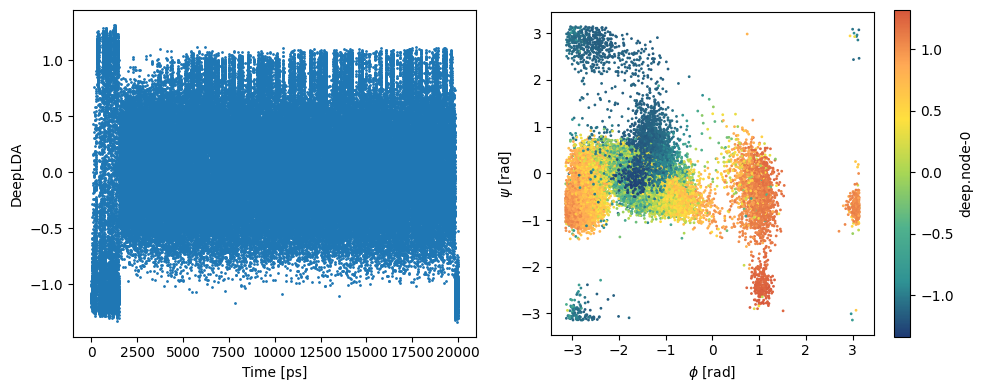

In [47]:
colvar_ml = load_dataframe(f"{folder_ml}/COLVAR")

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=100)
colvar_ml.plot.scatter('time', 'deep.node-0', s=1, ax=axs[0])
axs[0].set_xlabel('Time [ps]')
axs[0].set_ylabel('DeepLDA')

colvar_ml.plot.scatter('phi', 'psi', c='deep.node-0', s=1, cmap='fessa', ax=axs[1])
axs[1].set_xlabel(r'$\phi$ [rad]')
axs[1].set_ylabel(r'$\psi$ [rad]')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()


### 9.2 Ramachandran plot con FES marginali (funzione riutilizzata da `05_test.ipynb`)

In [41]:
from matplotlib.gridspec import GridSpec
def plot_ramachandran_fes(colvar, phi_col='phi', psi_col='psi', z_col='deep_lda',
                           bias_col='metad.bias', kbt=2.5, blocks=5,
                           bandwidth=0.01, fes_max=50.0, gridsize=150,
                           figsize=(8, 8)):
    """
    Ramachandran plot (pannello centrale, hexbin colorato da z_col) con FES
    marginali rispetto a phi (pannello superiore) e psi (pannello destro,
    assi ruotati), calcolate con mlcolvar.utils.fes.compute_fes.

    Parameters
    ----------
    colvar : pandas.DataFrame
        DataFrame delle variabili collettive (formato PLUMED COLVAR).
    phi_col, psi_col : str
        Colonne degli angoli diedri (in radianti, coerentemente con l'output
        nativo di PLUMED).
    z_col : str o None
        Colonna usata per colorare l'hexbin del Ramachandran plot (es. il
        valore della CV Deep-LDA). Se None o assente, hexbin colora per
        conteggio di punti nel bin.
    bias_col : str o None
        Colonna di bias (kJ/mol) per il reweighting boltzmanniano. Se None
        o assente, compute_fes riceve weights=None (traiettoria non biassata).
    kbt : float
        kT della simulazione in kJ/mol (2.5 kJ/mol ~ 300 K).
    blocks : int
        Numero di blocchi per la stima dell'errore via block-averaging.
    bandwidth : float
        Bandwidth del KDE in compute_fes.
    fes_max : float
        Limite superiore dell'asse F [kJ/mol] nei pannelli marginali.
    gridsize : int
        Risoluzione dell'hexbin nel pannello centrale.

    Returns
    -------
    fig, axes : dict con chiavi 'main', 'top', 'right', 'cbar'
    """
    phi = colvar[phi_col].values
    psi = colvar[psi_col].values
    z = colvar[z_col].values if (z_col is not None and z_col in colvar) else None

    # pesi per il reweighting boltzmanniano (Torrie & Valleau, J. Comput.
    # Phys. 23, 187-199, 1977; Tiwary & Parrinello, J. Phys. Chem. B 119,
    # 736-742, 2015), coerenti con lo schema OPES/metadinamica del pipeline
    if bias_col is not None and bias_col in colvar:
        w = np.exp(colvar[bias_col].values / kbt)
    else:
        w = None

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                  wspace=0.08, hspace=0.08, figure=fig)

    ax_main = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
    ax_cbar = fig.add_subplot(gs[0, 1])

    # ---------- pannello centrale: Ramachandran colorato da z_col ----------
    h = ax_main.hexbin(phi, psi, C=z, gridsize=gridsize, cmap='fessa')
    ax_main.set_xlabel(r'$\phi$ [rad]')
    ax_main.set_ylabel(r'$\psi$ [rad]')

    cbar = fig.colorbar(h, cax=ax_cbar)
    cbar.set_label(z_col if z is not None else 'counts')

    # ---------- pannello superiore: FES marginale rispetto a phi ----------
    compute_fes(phi, weights=w, kbt=kbt, blocks=blocks, bandwidth=bandwidth,
                plot=True, ax=ax_top)
    ax_top.set_xlabel('')
    ax_top.set_ylabel('F [kJ/mol]')
    ax_top.set_ylim(0, fes_max)
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # ---------- pannello destro: FES marginale rispetto a psi (ruotata) ----------
    # plot=False: compute_fes disegna solo lungo l'asse "naturale" (grid, fes);
    # per l'orientamento ruotato costruiamo il plot manualmente.
    fes_psi, grid_psi, _, err_psi = compute_fes(
        psi, weights=w, kbt=kbt, blocks=blocks, bandwidth=bandwidth,
        plot=False)
    ax_right.plot(fes_psi, grid_psi, color='k', lw=1.2)
    if err_psi is not None:
        ax_right.fill_betweenx(grid_psi, fes_psi - err_psi, fes_psi + err_psi,
                                color='k', alpha=0.2)
    ax_right.set_xlabel('F [kJ/mol]')
    ax_right.set_xlim(0, fes_max)
    plt.setp(ax_right.get_yticklabels(), visible=False)

    for a in (ax_top, ax_right):
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)

    return fig, {'main': ax_main, 'top': ax_top, 'right': ax_right, 'cbar': ax_cbar}

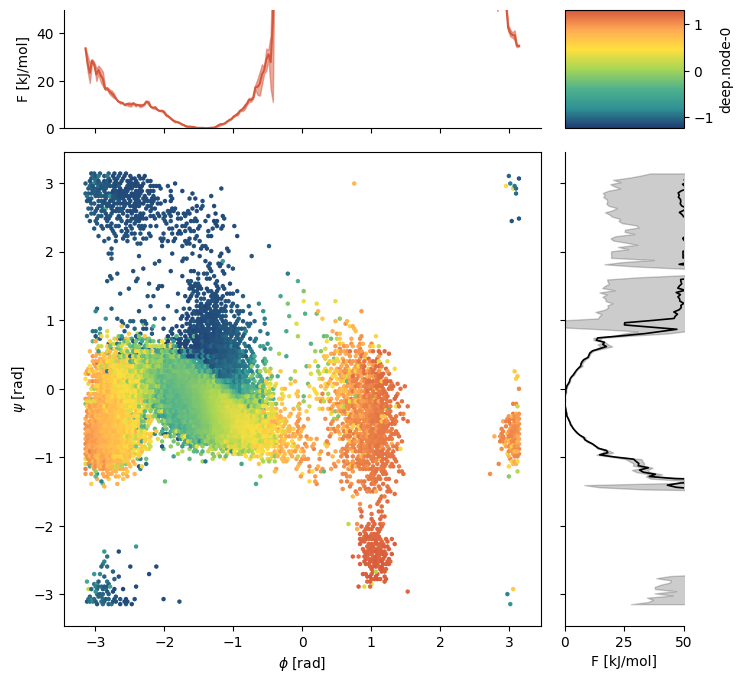

In [48]:
fig, axes = plot_ramachandran_fes(colvar_ml, z_col='deep.node-0', bias_col='metad.bias')
plt.show()


### 9.3 Deposito dei gaussiani (hills plot)

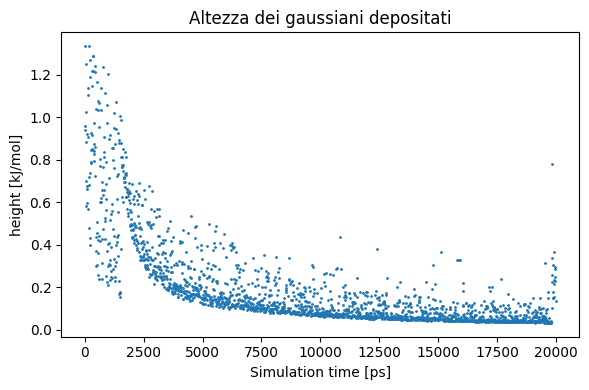

In [49]:
data_hills = load_dataframe(f"{folder_ml}/HILLS")

plt.figure(figsize=(6, 4), dpi=100)
plt.plot(data_hills["time"][::10], data_hills["height"][::10], 'o', ms=1)
plt.xlabel("Simulation time [ps]")
plt.ylabel("height [kJ/mol]")
plt.title("Altezza dei gaussiani depositati")
plt.tight_layout()


### 9.4 Convergenza della FES nel tempo (sum_hills) e stima di Delta F

La FES lungo la CV Deep-LDA e ricostruita a intervalli crescenti di simulazione tramite `plumed sum_hills`, per verificarne la convergenza. Si stima inoltre la differenza di energia libera tra i due bacini, integrando la probabilita in due intervalli rappresentativi della CV.

In [50]:
execute("plumed sum_hills --hills HILLS --stride 200 --mintozero", folder=folder_ml)


Completed: plumed sum_hills --hills HILLS --stride 200 --mintozero


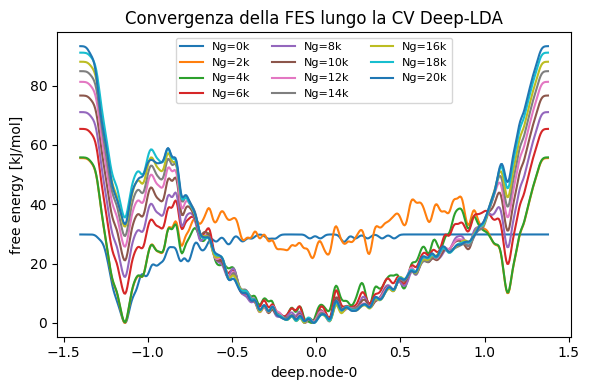

In [51]:
plt.figure(figsize=(6, 4), dpi=100)
for i in range(0, 101, 10):
    data = load_dataframe(f"{folder_ml}/fes_{i}.dat")
    plt.plot(data["deep.node-0"], data["file.free"], label=f"Ng={int(2*i/10)}k")

plt.xlabel("deep.node-0")
plt.ylabel("free energy [kJ/mol]")
plt.legend(ncol=3, fontsize=8)
plt.title("Convergenza della FES lungo la CV Deep-LDA")
plt.tight_layout()


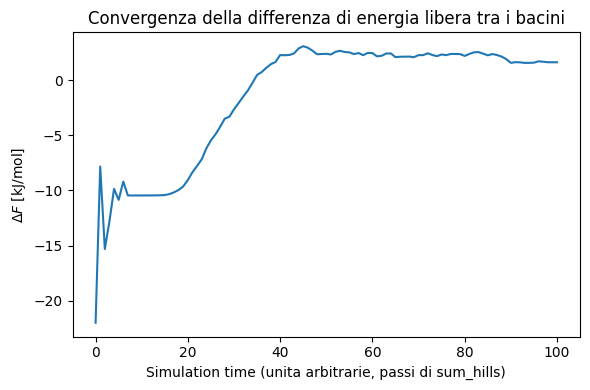

In [52]:
# Stima della differenza di energia libera tra i bacini in funzione del tempo di simulazione
# NOTA: gli intervalli di integrazione [-1.5,-0.5] e [0.5,1.5] vanno adattati alla posizione
# effettiva dei due minimi della CV Deep-LDA ottenuta in questo addestramento.
DeltaF = []
kbt = 2.494339

for i in range(0, 101):
    data = load_dataframe(f"{folder_ml}/fes_{i}.dat")
    minf = min(data["file.free"])
    F0 = 0.0
    F1 = 0.0
    for j in range(len(data["deep.node-0"])):
        dn = data["deep.node-0"][j]
        p = math.exp((-data["file.free"][j] + minf) / kbt)
        if -1.5 <= dn <= -0.5:
            F0 += p
        if 0.5 <= dn <= 1.5:
            F1 += p
    DeltaF.append(-kbt * math.log(F0 / F1))

plt.figure(figsize=(6, 4), dpi=100)
plt.plot(DeltaF)
plt.xlabel("Simulation time (unita arbitrarie, passi di sum_hills)")
plt.ylabel(r"$\Delta F$ [kJ/mol]")
plt.title("Convergenza della differenza di energia libera tra i bacini")
plt.tight_layout()


### 9.5 Reweighting su phi, psi e confronto con la FES da bias

Si esegue il reweighting boltzmanniano (Tiwary & Parrinello, J. Phys. Chem. B 2015, 119, 736-742) tramite `plumed driver`, ricalcolando la traiettoria con `METAD` in modalita `RESTART` a bias congelato, per ottenere le FES marginali lungo phi e psi e confrontarle con quella lungo la CV Deep-LDA.

In [53]:
folder_ml_rw = DATA_DIR / "8_deeplda-paper-rw/"
Path(folder_ml_rw).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_ml_rw)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_ml_rw)
execute(f"cp {folder_ml}/model.ptc .", folder_ml_rw)


Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data2/7_deeplda-paper/model.ptc .


In [54]:
with open(folder_ml_rw / "plumed_reweight.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2

INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

metad: METAD ARG=deep.node-0 ...
   PACE=10000000 HEIGHT=0.0 BIASFACTOR={BIASFACTOR_METAD}
   SIGMA={sigma_metad:.4f}
   FILE={folder_ml}/HILLS GRID_MIN=-pi GRID_MAX=pi
   RESTART=YES
...

as: REWEIGHT_BIAS ARG=metad.bias
hhphi: HISTOGRAM ARG=phi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as
hhpsi: HISTOGRAM ARG=psi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as
ffphi: CONVERT_TO_FES GRID=hhphi
ffpsi: CONVERT_TO_FES GRID=hhpsi
DUMPGRID GRID=ffphi FILE=ffphi.dat
DUMPGRID GRID=ffpsi FILE=ffpsi.dat

PRINT ARG=phi,psi,deep.node-0,metad.bias FILE=COLVAR_REWEIGHT STRIDE=1
ENDPLUMED
""")


In [55]:
execute(f"plumed driver --mf_xtc {folder_ml}/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339",
        folder=folder_ml_rw)


Completed: plumed driver --mf_xtc /home/dani/wslcoding/MCFM/ML-CV/data2/7_deeplda-paper/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339


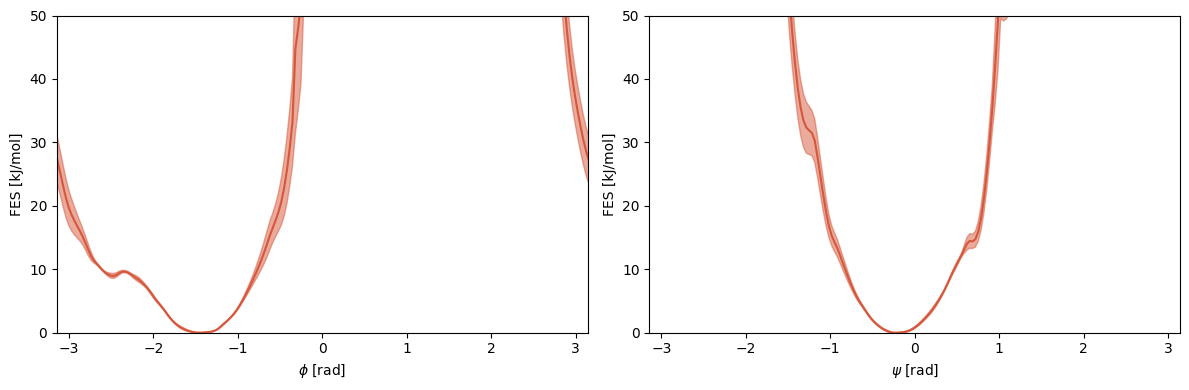

In [56]:
colvar_ml_rw = load_dataframe(f"{folder_ml_rw}/COLVAR_REWEIGHT")

kbT = 2.5
bandwidth = 0.05

phi_ml, w_phi_ml = augment_periodic(colvar_ml_rw['phi'].values,
                                     np.exp(colvar_ml_rw['metad.bias'].values / kbT), bandwidth)
psi_ml, w_psi_ml = augment_periodic(colvar_ml_rw['psi'].values,
                                     np.exp(colvar_ml_rw['metad.bias'].values / kbT), bandwidth)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=100)
for ax, (data, w, label) in zip(axs, [(phi_ml, w_phi_ml, r'$\phi$ [rad]'),
                                       (psi_ml, w_psi_ml, r'$\psi$ [rad]')]):
    compute_fes(data, weights=w, kbt=kbT, blocks=5, bandwidth=bandwidth, plot=True, ax=ax)
    ax.set_xlabel(label)
    ax.set_ylabel('FES [kJ/mol]')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(0, 50)
plt.tight_layout()


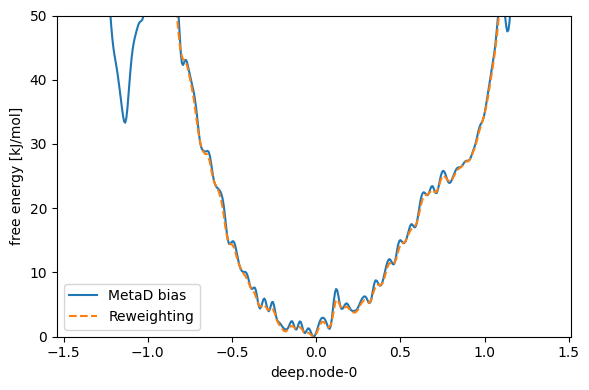

In [57]:
# Confronto diretto: FES da bias di metadinamica (deep.node-0) vs FES da reweighting (deep.node-0)
s_rw = colvar_ml_rw['deep.node-0'].values
w_rw = np.exp(colvar_ml_rw['metad.bias'].values / kbT)

fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
fes_rw, grid_rw, _, _ = compute_fes(s_rw, weights=w_rw, kbt=kbT, blocks=5, bandwidth=0.01, plot=False)

data_b = load_dataframe(f"{folder_ml}/fes_100.dat")
ax.plot(data_b["deep.node-0"], data_b["file.free"], label="MetaD bias")
ax.plot(grid_rw, fes_rw - min(fes_rw), label="Reweighting", linestyle='--')
ax.set_xlabel("deep.node-0")
ax.set_ylabel("free energy [kJ/mol]")
ax.set_ylim(0, 50)
ax.legend()
plt.tight_layout()


### 9.6 Correlazione tra la CV Deep-LDA, i descrittori e gli angoli diedri

IndexError: index 0 is out of bounds for axis 0 with size 0

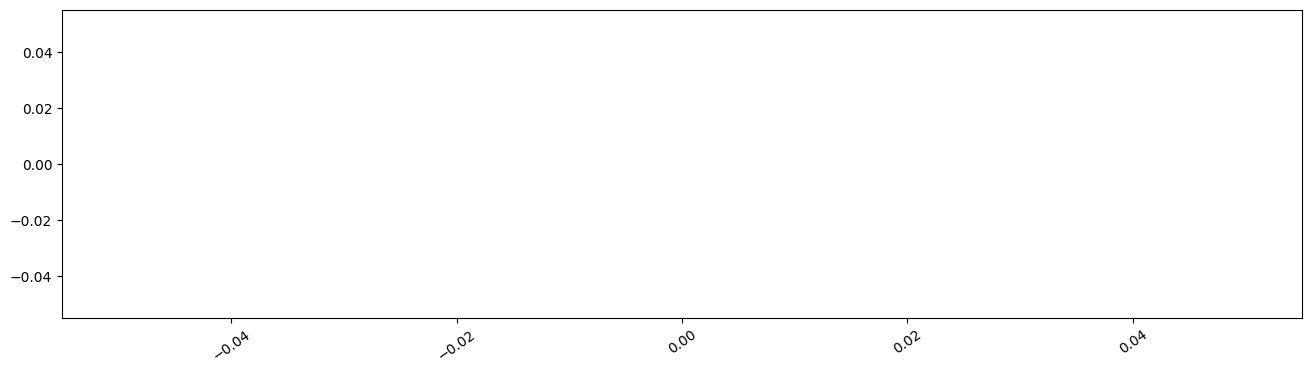

In [58]:
cols = ['deep.node-0']
cols.extend(colvar_ml.filter(regex='d_').columns)
corr = colvar_ml[cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(16, 4), dpi=100)
corr['deep.node-0'].drop('deep.node-0').plot(kind='bar', ax=ax, rot=35)
ax.set_ylabel('Correlazione (Pearson) con Deep-LDA')
plt.tight_layout()
plt.show()


In [ ]:
cols_angles = ['deep.node-0', 'phi', 'psi', 'theta', 'xi']
corr_angles = colvar_ml[cols_angles].corr(method='spearman')

fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
corr_angles['deep.node-0'].drop('deep.node-0').plot(kind='bar', ax=ax, rot=35)
ax.set_ylabel('Correlazione (Spearman) con Deep-LDA')
plt.tight_layout()
plt.show()


### 9.7 Block analysis (stima dell'errore statistico)

Si stima l'errore statistico sulla FES tramite block-averaging (Wu and Kofke, J. Chem. Phys. 2005, 123, 054103) sul reweighting lungo phi, riutilizzando lo script `do_block_fes.py` gia presente nella pipeline.

In [ ]:
folder_ml_bl = DATA_DIR / "9_deeplda-paper-block/"
Path(folder_ml_bl).mkdir(parents=True, exist_ok=True)

script_block_fes = str(BASE_DIR / "notebook/do_block_fes.py")

os.environ["DIR_3"] = str(folder_ml_rw)
os.environ["SCRIPT_FES"] = str(script_block_fes)

bash_script = """
bmax=`sort -n -k 5 "$DIR_3/COLVAR_REWEIGHT" | tail -n 1 | awk '{print $5}'`
awk '{if($1!="#!") print $2,exp(($5-bm)/2.494339)}' bm=$bmax "$DIR_3/COLVAR_REWEIGHT" > phi.weight

echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks
"""

execute(bash_script, folder=folder_ml_bl)


In [ ]:
data_block = load_dataframe(f"{folder_ml_bl}/err.blocks")

plt.figure(figsize=(6, 4), dpi=100)
plt.plot(data_block["bsize"], data_block["err"])
plt.xlabel("Block size")
plt.ylabel("Average error on free-energy profile [kJ/mol]")
plt.title("Block analysis della FES da reweighting (phi)")
plt.tight_layout()


## 10. Riepilogo

| Fase | Esito atteso |
|---|---|
| Training Deep-LDA | Separazione netta dei due stati (Fisher ratio elevato), loss di validazione convergente |
| Sensitivity analysis | Un sottoinsieme ristretto di distanze (tipicamente quelle coinvolgenti gli atomi del legame peptidico centrale) domina la CV, in modo stabile tra i seed |
| Sweep architettura/attivazione | La scelta raccomandata (tanh, 5 uscite pre-LDA) risulta un compromesso ragionevole tra qualita della separazione e stabilita del training |
| Metadinamica ben temperata | Transizioni multiple tra i bacini A/B entro la finestra di simulazione, FES convergente con l'aumentare del tempo simulato |
| Reweighting vs bias | Le FES lungo deep.node-0 ottenute dai due metodi devono coincidere entro l'errore statistico |
| Block analysis | L'errore stimato deve saturare (plateau) all'aumentare della dimensione del blocco, indicando decorrelazione delle stime |

Compilare questa sezione con i valori numerici ottenuti (Fisher ratio, Delta F tra i bacini, errore statistico a convergenza) una volta eseguite le simulazioni.
